<a href="https://colab.research.google.com/github/OceanYing/DearPyGui-3D-Operation-Example/blob/main/Copy_of_3D_Gaussian_projection_and_integration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

def rotation_matrix_from_axis_angle(axis, angle):
  """Constructs a rotation matrix from an axis-angle representation.

  Args:
    axis: A PyTorch tensor of shape (3,) representing the rotation axis (unit vector).
    angle: A PyTorch tensor representing the rotation angle in radians.

  Returns:
    A PyTorch tensor of shape (3, 3) representing the rotation matrix.
  """

  # Normalize the axis vector
  axis = axis / torch.norm(axis)

  # Calculate the skew-symmetric matrix of the axis
  skew_matrix = torch.tensor([
      [0, -axis[2], axis[1]],
      [axis[2], 0, -axis[0]],
      [-axis[1], axis[0], 0]
  ])

  # Use Rodrigues' rotation formula to compute the rotation matrix
  rotation_matrix = torch.eye(3) + torch.sin(angle) * skew_matrix + (1 - torch.cos(angle)) * torch.matmul(skew_matrix, skew_matrix)

  return rotation_matrix

In [ ]:
# prompt: make a 4x(nxm) matrix that contains all the pixel coordinates of an nxm image ; add a third and a fourth row with ones to represent the pixels as points using homogeneous coordinates

import numpy as np
def pixel_coordinates(n,m):
    x, y = np.meshgrid(np.arange(m), np.arange(n))
    pixel_coords = np.zeros((2, n*m))
    pixel_coords[0] = x.ravel()
    pixel_coords[1] = y.ravel()
    pixel_coords = np.vstack((pixel_coords, np.ones((1, n*m)), np.ones((1, n*m))))
    return torch.tensor(pixel_coords, dtype=torch.float32)

In [ ]:
# prompt: make a perspective projection matrix with a view frustum of 90 degrees, near plane at 0.1, far plane at 10; make a viewport transformation matrix for a 100x100 image

import torch
import math
import numpy as np

# Create a perspective projection matrix
near = 0.1
far = 10
fov = 90
deg2rad = math.acos(-1.0) / 180
aspectRatio = 1

tangent = math.tan(fov/2 * deg2rad)
top = near * tangent;
right = top * aspectRatio;

P = torch.zeros(4, 4)
P[0, 0] = near/right
P[1, 1] = near/top
P[2, 2] = -(far+near)/(far-near)
P[2, 3] = -(2 * near * far)/(far-near)
P[3, 2] = -1

# Create a viewport transformation matrix
xres = 50
yres = 50
VP_scale = torch.zeros(4, 4)
VP_scale[0, 0] = xres / 2
VP_scale[1, 1] = yres / 2
VP_scale[2, 2] = 1
VP_scale[3, 3] = 1
VP_trans = torch.eye(4, 4)
VP_trans[0, 3] = xres / 2 - 0.5
VP_trans[1, 3] = yres / 2 - 0.5
VP = VP_trans @ VP_scale


In [ ]:
# Just for testing the projection matrix
e = torch.tensor([[near],[near],[-near],[1.0]])
P_e = P @ e
e = torch.tensor([[1.0],[1.0],[1.0],[1.0]])
invP = torch.inverse(P)
invP_e = invP @ e
print(P_e)
print(invP_e)

tensor([[ 0.1000],
        [ 0.1000],
        [-0.1000],
        [ 0.1000]])
tensor([[ 1.0000],
        [ 1.0000],
        [-1.0000],
        [ 0.1000]])


In [ ]:
# Make tensor containing pixel coordinates
pc = pixel_coordinates(xres,yres)
# Convert pixel coordinates to unified device coordinates (udc, by definition a square [-1,-1]x[1,1]) using inverse viewport transformation
udc = torch.inverse(VP) @ pc
# Convert udc to camera coordinates by applying inverse projection (the projection matrix is designed to convert camera coordinates to udc; here we are doing the inverse to map back to camera space); cc then represents a direction vector through each pixel, expressed in camera coordinates
cc = torch.inverse(P) @ udc
cc = cc/cc[3]
cc[3,:] = 0
cc = cc/torch.abs(cc[2,:])

# Construct per-pixel coordinate systems to integrate Gaussian; coordinate basis vectors are expressed in camera coordinates
# First two coordinates are parallel to image plane, that is, same as basis vectors of camera coordinates
# Third coordinate is direction through camera center, along which we will integrate the 3D Gaussian

# gic is the per pixel coordinate transform from sheared-Gaussian to camera coordinates, using homogeneous coordinates; i.e, the columns of gic contain the basis vectors of the sheared-Gaussian coordinate system expressed in camera coordinates; there is a separate gic coordinate system for each pixel!
gic=torch.zeros(xres*yres,4,4)
# The first two axes of the gic coordinate system are parallel to the image plane, that is, the basis vectors are [1 0 0 0] and [0 1 0 0]
gic[:] = torch.eye(4)
# The third axes is the direction of a ray through each pixel
gic[:,:,2] = cc.t()
# Put the origin of the gic coordinate system at the mean of the Gaussian that we are rendering
gaussian_mean = torch.tensor([2.0,1.0,-5.0,1.0],requires_grad=True)
gic[:,:,3] = gaussian_mean.repeat(xres*yres,1)
# The inverse of gic represents the coordinate transform from camera coordinates to gic
inv_gic = torch.inverse(gic)
# We transform the origin of camera coordinate, which is [0 0 0 1], to each pixel's gic coordinate system; the resulting first two dimensions in gic are the locations where we will need to evaluate the integrated Gaussian
evalpts = inv_gic[:,0:2,3]
evalpts = evalpts.unsqueeze(2)

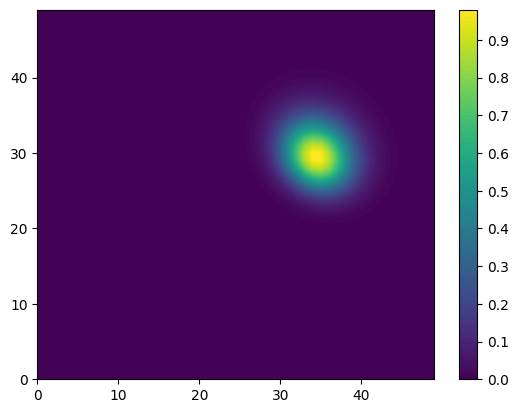

In [ ]:
# Define inverse of variance of the Gaussian we want to render, repeated at each pixel; we define this matrix in camera coordinates
scale = torch.tensor([4.0],requires_grad=True)
Vinv = torch.tensor([[1.0, 0.0, 0.0],[0.0, 1.0, 0.0],[0.0, 0.0, 1.0]])
Vinv = Vinv.repeat(xres*yres, 1, 1)
Vinv[:,0,0] = scale
Vinv[:,1,1] = scale
Vinv[:,2,2] = scale*0.5
# Apply some rotation to the Gaussian
axis = torch.tensor([1.0, 1.0, 0.0])  # Rotation around X-axis
angle = torch.tensor(torch.pi / 3)  # 90 degrees rotation
rotation_matrix = rotation_matrix_from_axis_angle(axis, angle)
rotation_matrix = rotation_matrix.repeat(xres*yres, 1, 1)
Vinv_rot = torch.matmul(torch.transpose(rotation_matrix,1,2),torch.matmul(Vinv, rotation_matrix))

# Calculate the sheared inverse covariance per pixel, first in 3D, then integrate to 2D
# First, the 3D per pixel shearing matrix
gic3x3 = gic[:,:3,:3]
# Apply the per pixel shear to the inverse covariance
Vinv_sheared = torch.matmul(torch.transpose(gic3x3,1,2),torch.matmul(Vinv_rot, gic3x3))
# Get the covariance
V_sheared = torch.inverse(Vinv_sheared)
# Integrate along sheared (3rd) axis by retaining only first two axes, yielding 2D covariance matrix
V_sheared2x2 = V_sheared[:,:2,:2]
# Get inverse 2D covariance matrices
Vinv_sheared2x2 = torch.inverse(V_sheared2x2)
# Finally, evaluate the integrated Gaussian at all pixels of the image
evalpts_t = torch.transpose(evalpts,1,2)
d = evalpts_t @ torch.bmm(Vinv_sheared2x2, evalpts)
exp_d = torch.exp(-0.5*d)

# Plot the rendered Gaussian
import matplotlib.pyplot as plt
image = exp_d.reshape(xres,yres)

image = image.detach()
plt.contourf(image, levels = 100)
plt.colorbar()
plt.show()

In [ ]:
# Gradient calculation of each pixel value with respect to the mean and scaling of the Gaussian
gradients = []
for i in range(exp_d.size(0)):
    gradient_tensor = torch.zeros_like(exp_d)
    gradient_tensor[i] = 1.0
    gaussian_mean.grad = None
    scale.grad = None
    exp_d.backward(gradient_tensor, retain_graph=True)
    gradients.append(torch.cat((gaussian_mean.grad, scale.grad), dim=0))

gradients_tensor = torch.stack(gradients, dim=0)

In [ ]:
# Compute the Fisher by summing the outer products of all per-pixel Gradients
# Note that we are skipping the third element here, which is the gradient wrt. the homogeneous coordinate of the mean and we don't want this
outer_products = torch.bmm(gradients_tensor[:, [0,1,2,4]].unsqueeze(2), gradients_tensor[:, [0,1,2,4]].unsqueeze(1))
fisher = torch.sum(outer_products, dim=0)
eigenvalues, eigenvectors = torch.linalg.eigh(fisher)
print(fisher)
print(eigenvalues)
print(eigenvectors)

tensor([[44.0160,  5.9905, 19.0542, -0.1560],
        [ 5.9905, 37.6956, 10.4010, -0.2910],
        [19.0542, 10.4010, 12.3240, -1.6389],
        [-0.1560, -0.2910, -1.6389,  0.9489]])
tensor([3.3827e-07, 2.9226e+00, 3.4099e+01, 5.7963e+01])
tensor([[ 0.2063,  0.3208,  0.4937, -0.7815],
        [ 0.1031,  0.1711, -0.8694, -0.4518],
        [-0.5157, -0.7409,  0.0164, -0.4299],
        [-0.8251,  0.5647,  0.0045,  0.0168]])


In [ ]:
# The smallest eigenvector contains the expected direction!
eigenvectors[:,0]/eigenvectors[2,0]

tensor([-0.4000, -0.2000,  1.0000,  1.6000])